In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import xarray as xr
from scipy.stats import pearsonr

from sst_pix2pix_annual_cycle import Generator, rollout_prediction, get_seasonal_encoding
from train_cmip6_sst import denormalize_data, load_and_process_cmip6_data
from utils import save_rollout_to_netcdf,save_rollout_to_netcdf_new

In [2]:
# ============================================================================
# Load Trained Model
# ============================================================================

def load_trained_model(checkpoint_path, device='cpu'):
    """
    Load trained generator from checkpoint.
    
    Args:
        checkpoint_path: Path to checkpoint file
        device: 'cuda' or 'cpu'
    
    Returns:
        generator, climatology, norm_params, num_input_months
    """
    print(f"Loading checkpoint from: {checkpoint_path}")
    checkpoint = torch.load(checkpoint_path, map_location=device)
    
    num_input_months = checkpoint['num_input_months']
    in_channels = num_input_months + 2
    
    generator = Generator(in_channels=in_channels, features=128, out_channels=1).to(device)
    generator.load_state_dict(checkpoint['generator_state_dict'])
    generator.eval()
    
    climatology = checkpoint['climatology']
    norm_params = checkpoint['norm_params']
    
    print(f"Model loaded from epoch {checkpoint['epoch']}")
    if 'best_val_loss' in checkpoint:
        print(f"Best validation loss: {checkpoint['best_val_loss']:.4f}")
    
    return generator, climatology, norm_params, num_input_months



In [3]:
# ============================================================================
# COBE Data Processing
# ============================================================================

def load_and_process_cobe_data(dataset_path, mask_path='../../Data/mask.npy', 
                                 n_train=1428, n_val=100, ensemble_id=0):
    """
    Load and process COBE SST data.
    
    Args:
        dataset_path: Path to COBE netCDF file
        mask_path: Path to mask file
        n_train: Number of training samples
        n_val: Number of validation samples
        ensemble_id: Which ensemble member to use (if multiple)
    
    Returns:
        train_data, val_data, test_data, train_months, val_months, test_months, mask
    """
    print(f"Loading dataset from: {dataset_path}")
    
    # Load dataset
    ds = xr.open_dataset(dataset_path)
    
    # Select SST variable
    sst = ds["sst"]
    
    # climatology = sst.groupby("time.month").mean(dim="time")
    # sst = sst.groupby("time.month")-climatology
    sst = sst.fillna(0)

    data = sst.values  # Shape: (time, lat, lon)
    
    print(f"Data shape: {data.shape}")
    print(f"Data range: [{data.min():.2f}, {data.max():.2f}]")
    
    # Load mask
    mask = np.load(mask_path)
    print(f"Mask shape: {mask.shape}")
    
    # Split data
    train_data = data[:n_train, :, :]
    val_data = data[n_train:n_train + n_val, :, :]
    test_data = data[n_train:, :, :]
    
    print(f"Train shape: {train_data.shape}")
    print(f"Val shape: {val_data.shape}")
    print(f"Test shape: {test_data.shape}")
    
    # Create month arrays (0-11 for each sample)
    # Assuming data starts from a known month, or extract from dataset
    # If your dataset has months encoded, extract them. Otherwise:
    total_samples = data.shape[0]
    
    # Try to get starting month from dataset metadata
    if 'mon' in ds.coords:
        # If months are in coordinates, use them
        months_all = np.array([(i % 12) for i in range(total_samples)])
    else:
        # Default: assume data starts in January (month 0)
        months_all = np.array([i % 12 for i in range(total_samples)])
    
    train_months = months_all[:n_train]
    val_months = months_all[n_train:n_train + n_val]
    test_months = months_all[n_train:]
    
    return train_data, val_data, test_data, train_months, val_months, test_months, mask


In [4]:
# ============================================================================
# Evaluation Functions
# ============================================================================

def evaluate_single_step(generator, test_data, test_months, num_input_months, 
                         climatology, norm_params, device='cpu'):
    """
    Evaluate single-step predictions on test set.
    
    Args:
        generator: trained generator
        test_data: test SST data (normalized)
        test_months: month indices
        num_input_months: number of input months
        climatology: monthly climatology
        norm_params: normalization parameters
        device: computation device
    
    Returns:
        metrics dictionary
    """
    from sst_pix2pix_annual_cycle import SSTDataset
    from torch.utils.data import DataLoader
    
    print("\n" + "="*70)
    print("Evaluating Single-Step Predictions")
    print("="*70)
    
    # Create test dataset
    test_dataset = SSTDataset(
        sst_data=test_data,
        months=test_months,
        num_input_months=num_input_months,
        climatology=climatology
    )
    
    test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)
    
    all_predictions = []
    all_targets = []
    all_months = []
    
    generator.eval()
    with torch.no_grad():
        for batch in test_loader:
            inputs = batch['input'].to(device)
            targets = batch['target'].to(device)
            target_months = batch['target_month']
            
            predictions = generator(inputs)
            
            all_predictions.append(predictions.cpu().numpy())
            all_targets.append(targets.cpu().numpy())
            all_months.extend(target_months.numpy())
    
    # Concatenate all predictions
    predictions = np.concatenate(all_predictions, axis=0).squeeze(1)  # (N, 48, 144)
    targets = np.concatenate(all_targets, axis=0).squeeze(1)
    all_months = np.array(all_months)
    
    # Denormalize
    predictions = denormalize_data(predictions, norm_params)
    targets = denormalize_data(targets, norm_params)
    
    # Compute metrics
    mae = np.mean(np.abs(predictions - targets))
    rmse = np.sqrt(np.mean((predictions - targets) ** 2))
    
    # Month-wise metrics
    month_mae = []
    month_rmse = []
    for month in range(12):
        month_mask = all_months == month
        if month_mask.sum() > 0:
            month_pred = predictions[month_mask]
            month_target = targets[month_mask]
            month_mae.append(np.mean(np.abs(month_pred - month_target)))
            month_rmse.append(np.sqrt(np.mean((month_pred - month_target) ** 2)))
        else:
            month_mae.append(np.nan)
            month_rmse.append(np.nan)
    
    print(f"\nOverall Metrics:")
    print(f"  MAE:  {mae:.4f} K")
    print(f"  RMSE: {rmse:.4f} K")
    
    print(f"\nMonth-wise RMSE:")
    month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                   'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
    for i, (name, val) in enumerate(zip(month_names, month_rmse)):
        if not np.isnan(val):
            print(f"  {name}: {val:.4f} K")
    
    metrics = {
        'mae': mae,
        'rmse': rmse,
        'month_mae': month_mae,
        'month_rmse': month_rmse,
        'predictions': predictions,
        'targets': targets,
        'months': all_months
    }
    
    return metrics


def evaluate_rollout(generator, test_data, test_months, num_input_months, 
                     climatology, norm_params, num_rollout_months=24, 
                     num_rollouts=10, device='cuda'):
    """
    Evaluate multi-month rollout predictions.
    
    Args:
        generator: trained generator
        test_data: test SST data (normalized)
        test_months: month indices
        num_input_months: number of input months
        climatology: monthly climatology
        norm_params: normalization parameters
        num_rollout_months: how many months to predict
        num_rollouts: how many different starting points to test
        device: computation device
    
    Returns:
        rollout results and metrics
    """
    print("\n" + "="*70)
    print(f"Evaluating {num_rollout_months}-Month Rollout Predictions")
    print("="*70)
    
    all_rollout_predictions = []
    all_rollout_targets = []
    
    print("length of test data: "+str(len(test_data)))

    # Perform multiple rollouts from different starting points
    step_size = max(1, (len(test_data) - num_input_months - num_rollout_months) // num_rollouts)
    
    for i in range(num_rollouts):
        start_idx = num_input_months + i * step_size
        
        if start_idx + num_rollout_months >= len(test_data):
            break
        
        # Get initial inputs
        initial_inputs = torch.FloatTensor(test_data[start_idx-num_input_months:start_idx])
        initial_month = test_months[start_idx - 1]
        
        # Perform rollout
        predictions = rollout_prediction(
            generator, initial_inputs, initial_month, 
            num_months=num_rollout_months
        )
        
        # Get ground truth
        targets = test_data[start_idx:start_idx+num_rollout_months]
        
        all_rollout_predictions.append(np.array(predictions))
        all_rollout_targets.append(targets)
    
    # Convert to arrays
    rollout_predictions = np.array(all_rollout_predictions)  # (num_rollouts, num_months, 48, 144)
    rollout_targets = np.array(all_rollout_targets)
    
    # Denormalize
    rollout_predictions = denormalize_data(rollout_predictions, norm_params)
    rollout_targets = denormalize_data(rollout_targets, norm_params)
    
    # Compute metrics over time
    rollout_mae_vs_time = []
    rollout_rmse_vs_time = []
    print('Roll-out shape: '+str(rollout_predictions.shape))
    for t in range(num_rollout_months):
        mae_t = np.nanmean(np.abs(rollout_predictions[:, t] - rollout_targets[:, t]))
        rmse_t = np.sqrt(np.nanmean((rollout_predictions[:, t] - rollout_targets[:, t]) ** 2))
        rollout_mae_vs_time.append(mae_t)
        rollout_rmse_vs_time.append(rmse_t)
    
    print(f"\nRollout RMSE over time:")
    for t in range(min(12, num_rollout_months)):
        print(f"  Month {t+1}: {rollout_rmse_vs_time[t]:.4f} K")
    
    # Check annual cycle preservation
    if num_rollout_months >= 24:
        year1_preds = rollout_predictions[:, 0:12].mean(axis=(0, 2, 3))
        year2_preds = rollout_predictions[:, 12:24].mean(axis=(0, 2, 3))
        cycle_correlation = pearsonr(year1_preds, year2_preds)[0]
        print(f"\nAnnual cycle consistency (year 1 vs year 2): {cycle_correlation:.4f}")
    
    results = {
        'predictions': rollout_predictions,
        'targets': rollout_targets,
        'mae_vs_time': rollout_mae_vs_time,
        'rmse_vs_time': rollout_rmse_vs_time
    }
    
    return results


def compare_with_climatology(predictions, targets, months, climatology, norm_params):
    """
    Compare predictions with climatology baseline.
    
    Args:
        predictions: model predictions (denormalized)
        targets: ground truth (denormalized)
        months: month indices
        climatology: monthly climatology (normalized)
        norm_params: normalization parameters
    """
    print("\n" + "="*70)
    print("Comparison with Climatology Baseline")
    print("="*70)
    
    # Denormalize climatology
    climatology_denorm = denormalize_data(climatology, norm_params)
    
    # Get climatology predictions for test months
    clim_predictions = np.array([climatology_denorm[m] for m in months])
    
    # Model metrics
    model_mae = np.mean(np.abs(predictions - targets))
    model_rmse = np.sqrt(np.mean((predictions - targets) ** 2))
    
    # Climatology metrics
    clim_mae = np.mean(np.abs(clim_predictions - targets))
    clim_rmse = np.sqrt(np.mean((clim_predictions - targets) ** 2))
    
    # Skill score
    skill_score = 1 - (model_rmse / clim_rmse)
    
    print(f"\nModel Performance:")
    print(f"  MAE:  {model_mae:.4f} K")
    print(f"  RMSE: {model_rmse:.4f} K")
    
    print(f"\nClimatology Baseline:")
    print(f"  MAE:  {clim_mae:.4f} K")
    print(f"  RMSE: {clim_rmse:.4f} K")
    
    print(f"\nSkill Score: {skill_score:.4f}")
    if skill_score > 0:
        print("✓ Model outperforms climatology!")
    else:
        print("✗ Model underperforms climatology")
    
    return skill_score


In [5]:
lon_sst=np.array([  0.      ,   2.493056,   4.986111,   7.479167,   9.972222,  12.465278,
        14.958333,  17.451389,  19.944444,  22.4375  ,  24.930556,  27.423611,
        29.916667,  32.409722,  34.902778,  37.395833,  39.888889,  42.381944,
        44.875   ,  47.368056,  49.861111,  52.354167,  54.847222,  57.340278,
        59.833333,  62.326389,  64.819444,  67.3125  ,  69.805556,  72.298611,
        74.791667,  77.284722,  79.777778,  82.270833,  84.763889,  87.256944,
        89.75    ,  92.243056,  94.736111,  97.229167,  99.722222, 102.215278,
       104.708333, 107.201389, 109.694444, 112.1875  , 114.680556, 117.173611,
       119.666667, 122.159722, 124.652778, 127.145833, 129.638889, 132.131944,
       134.625   , 137.118056, 139.611111, 142.104167, 144.597222, 147.090278,
       149.583333, 152.076389, 154.569444, 157.0625  , 159.555556, 162.048611,
       164.541667, 167.034722, 169.527778, 172.020833, 174.513889, 177.006944,
       179.5     , 181.993056, 184.486111, 186.979167, 189.472222, 191.965278,
       194.458333, 196.951389, 199.444444, 201.9375  , 204.430556, 206.923611,
       209.416667, 211.909722, 214.402778, 216.895833, 219.388889, 221.881944,
       224.375   , 226.868056, 229.361111, 231.854167, 234.347222, 236.840278,
       239.333333, 241.826389, 244.319444, 246.8125  , 249.305556, 251.798611,
       254.291667, 256.784722, 259.277778, 261.770833, 264.263889, 266.756944,
       269.25    , 271.743056, 274.236111, 276.729167, 279.222222, 281.715278,
       284.208333, 286.701389, 289.194444, 291.6875  , 294.180556, 296.673611,
       299.166667, 301.659722, 304.152778, 306.645833, 309.138889, 311.631944,
       314.125   , 316.618056, 319.111111, 321.604167, 324.097222, 326.590278,
       329.083333, 331.576389, 334.069444, 336.5625  , 339.055556, 341.548611,
       344.041667, 346.534722, 349.027778, 351.520833, 354.013889, 356.506944])

lat_sst=np.array([-8.950000e+01, -8.577083e+01, -8.204167e+01, -7.831250e+01,
       -7.458333e+01, -7.085417e+01, -6.712500e+01, -6.339583e+01,
       -5.966667e+01, -5.593750e+01, -5.220833e+01, -4.847917e+01,
       -4.475000e+01, -4.102083e+01, -3.729167e+01, -3.356250e+01,
       -2.983333e+01, -2.610417e+01, -2.237500e+01, -1.864583e+01,
       -1.491667e+01, -1.118750e+01, -7.458333e+00, -3.729167e+00,
        1.136868e-13,  3.729167e+00,  7.458333e+00,  1.118750e+01,
        1.491667e+01,  1.864583e+01,  2.237500e+01,  2.610417e+01,
        2.983333e+01,  3.356250e+01,  3.729167e+01,  4.102083e+01,
        4.475000e+01,  4.847917e+01,  5.220833e+01,  5.593750e+01,
        5.966667e+01,  6.339583e+01,  6.712500e+01,  7.085417e+01,
        7.458333e+01,  7.831250e+01,  8.204167e+01,  8.577083e+01])

In [6]:
#!pip install basemap
import matplotlib.pyplot as plt
from mpl_toolkits.basemap import Basemap
import numpy as np
def plot_map(lon,lat,data,file_name):
#     m = Basemap(projection='cyl', resolution='l',
#             llcrnrlat=np.min(lat), urcrnrlat=np.max(lat),
#             llcrnrlon=np.min(lon), urcrnrlon=np.max(lon), )

    m = Basemap(projection='cyl', resolution='l',
            llcrnrlat=np.min(lat_sst), urcrnrlat=np.max(lat_sst),
            llcrnrlon=np.min(lon_sst), urcrnrlon=np.max(lon_sst), )
    #m.drawcoastlines()
    #plt.show()
    lons,lats= np.meshgrid(lon,lat)
    x,y = m(lons,lats)
    
    #m.drawcoastlines()
    levels = np.linspace(min(np.unique(data)),max(np.unique(data)),21)
    #levels = np.linspace(0.0,1.0,21)
    #levels=[-30,-20,-12,-9,-6,-2,-1,+1,+2,+6,+9,+12,+20,+30]
    temp = m.contourf(x,y,data,levels=levels,cmap='seismic')
    cb = m.colorbar(temp,"bottom", size="15%", pad="10%")
    m.drawcoastlines()
    m.drawparallels(np.arange(-90., 91., 30.), labels=[1, 0, 0, 0])
    m.drawmeridians(np.arange(0., 361., 45.), labels=[0, 0, 0, 1])
    #plt.title('sst')
    #cb.set_label('sst')

    plt.savefig(file_name)
    


    plt.show()
    plt.clf()



In [7]:
# ============================================================================
# Visualization Functions
# ============================================================================

def plot_sample_predictions(predictions, targets, months, num_samples=6, 
                            save_path='sample_predictions.png'):
    """Plot sample predictions vs ground truth."""
    fig, axes = plt.subplots(num_samples, 2, figsize=(12, 3*num_samples))
    
    month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                   'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
    
    # Select random samples
    indices = np.random.choice(len(predictions), num_samples, replace=False)
    
    for i, idx in enumerate(indices):
        month_name = month_names[months[idx]]
        
        
        # Ground truth
        im1 = axes[i, 0].imshow(np.flip(targets[idx],axis=0), cmap='RdBu_r', aspect='auto')
        axes[i, 0].set_title(f'{month_name} - Ground Truth')
        axes[i, 0].axis('off')
        plt.colorbar(im1, ax=axes[i, 0], fraction=0.046)
        
        # Prediction
        im2 = axes[i, 1].imshow(np.flip(predictions[idx],axis=0), cmap='RdBu_r', aspect='auto')
        axes[i, 1].set_title(f'{month_name} - Prediction')
        axes[i, 1].axis('off')
        plt.colorbar(im2, ax=axes[i, 1], fraction=0.046)
    
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"Sample predictions saved to: {save_path}")
    plt.close()


def plot_rollout_comparison(rollout_results, start_month=0, 
                            save_path='rollout_comparison.png'):
    """Plot rollout predictions for a full year."""
    #predictions = rollout_results['predictions'][0, :12]  # First rollout, 12 months
    predictions = rollout_results['predictions'][0, :]  # First rollout, all months
    predictions=predictions.reshape(40, 12, 48, 144).mean(axis=0)
    print(rollout_results['predictions'].shape)
    #targets = rollout_results['targets'][0, :12]
    #targets = rollout_results['targets'][0, :].reshape(40, 12, 48, 144).mean(axis=0)
    
    # fig, axes = plt.subplots(2, 6, figsize=(18, 6))
    
    # month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
    #                'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
    
    # vmin = min(predictions.min(), targets.min())
    # vmax = max(predictions.max(), targets.max())
    
    # for i in range(12):
    #     row = i // 6
    #     col = i % 6
    #     month_idx = (start_month + i) % 12
        
    #     if row == 0:
    #         # Ground truth
    #         im = axes[row, col].imshow(np.flip(targets[i],axis=0), cmap='RdBu_r', aspect='auto', 
    #                                    vmin=vmin, vmax=vmax)
    #         axes[row, col].set_title(f'{month_names[month_idx]} (Truth)')
    #     else:
    #         # Prediction
    #         im = axes[row, col].imshow(np.flip(predictions[i],axis=0), cmap='RdBu_r', aspect='auto',
    #                                    vmin=vmin, vmax=vmax)
    #         axes[row, col].set_title(f'{month_names[month_idx]} (Pred)')
        
    #     axes[row, col].axis('off')
    
    # plt.tight_layout()
    # plt.savefig(save_path, dpi=300, bbox_inches='tight')
    # print(f"Rollout comparison saved to: {save_path}")
    # plt.close()
    for i in range(12):
        print('Month: '+str(i+1))
        plot_map(lon_sst,lat_sst,rollout_results['predictions'][0, i],'../../Data/output/Temp/seasonal_pattern'+str(i+1)+'.png')


def plot_error_vs_lead_time(rollout_results, save_path='error_vs_leadtime.png'):
    """Plot how error grows with lead time."""
    mae_vs_time = rollout_results['mae_vs_time']
    rmse_vs_time = rollout_results['rmse_vs_time']
    
    fig, ax = plt.subplots(figsize=(10, 6))
    
    months = np.arange(1, len(mae_vs_time) + 1)
    ax.plot(months, rmse_vs_time, 'o-', label='RMSE', linewidth=2)
    ax.plot(months, mae_vs_time, 's-', label='MAE', linewidth=2)
    
    ax.set_xlabel('Lead Time (months)', fontsize=12)
    ax.set_ylabel('Error (K)', fontsize=12)
    ax.set_title('Prediction Error vs Lead Time', fontsize=14)
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"Error vs lead time plot saved to: {save_path}")
    plt.close()


Loading checkpoint from: ./checkpoints_COBE/best_model.pth
Model loaded from epoch 161
Best validation loss: 1.8034
Loading dataset from: ../../Data/COBE_SST_resize.nc
Data shape: (2099, 48, 144)
Data range: [-2.75, 33.23]
Mask shape: (48, 144)
Train shape: (1428, 48, 144)
Val shape: (100, 48, 144)
Test shape: (671, 48, 144)
Standardization - Mean: 8.7981, Std: 11.3378

Evaluating Single-Step Predictions


/home/deepayan/anaconda3/envs/test/lib/python3.9/site-packages/torch/nn/modules/conv.py:456: UserWarning: Using padding='same' with even kernel lengths and odd dilation may require a zero-padded copy of the input be created (Triggered internally at ../aten/src/ATen/native/Convolution.cpp:1040.)
  return F.conv2d(input, weight, bias, self.stride,



Overall Metrics:
  MAE:  0.2504 K
  RMSE: 0.3985 K

Month-wise RMSE:
  Jan: 0.3773 K
  Feb: 0.3900 K
  Mar: 0.3821 K
  Apr: 0.3757 K
  May: 0.3664 K
  Jun: 0.3882 K
  Jul: 0.4305 K
  Aug: 0.4806 K
  Sep: 0.4417 K
  Oct: 0.3869 K
  Nov: 0.3699 K
  Dec: 0.3742 K

Evaluating 480-Month Rollout Predictions
length of test data: 671
Roll-out shape: (1, 480, 48, 144)

Rollout RMSE over time:
  Month 1: 0.3125 K
  Month 2: 0.3628 K
  Month 3: 0.4205 K
  Month 4: 0.3620 K
  Month 5: 0.4045 K
  Month 6: 0.3966 K
  Month 7: 0.3628 K
  Month 8: 0.3654 K
  Month 9: 0.3973 K
  Month 10: 0.4190 K
  Month 11: 0.4101 K
  Month 12: 0.4594 K

Annual cycle consistency (year 1 vs year 2): 0.7356

Comparison with Climatology Baseline

Model Performance:
  MAE:  0.2504 K
  RMSE: 0.3985 K

Climatology Baseline:
  MAE:  0.3068 K
  RMSE: 0.5364 K

Skill Score: 0.2572
✓ Model outperforms climatology!

Generating visualizations...
Sample predictions saved to: sample_predictions.png
(1, 480, 48, 144)
Month: 1


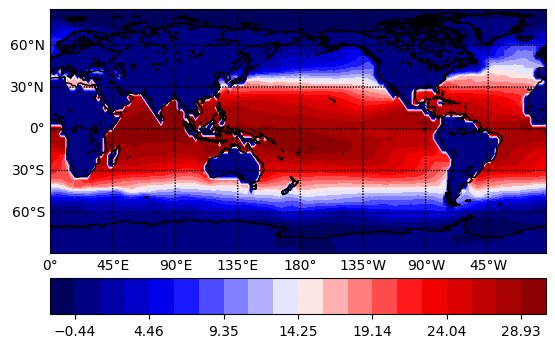

Month: 2


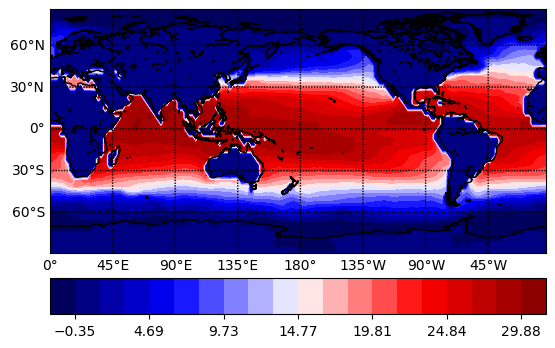

Month: 3


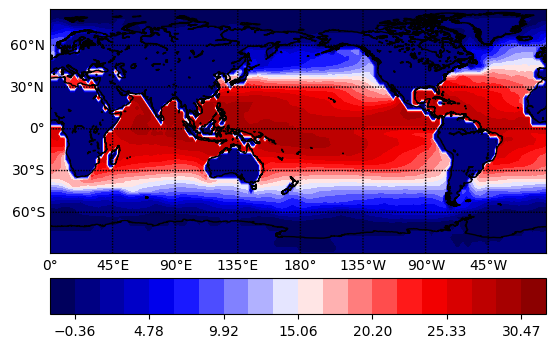

Month: 4


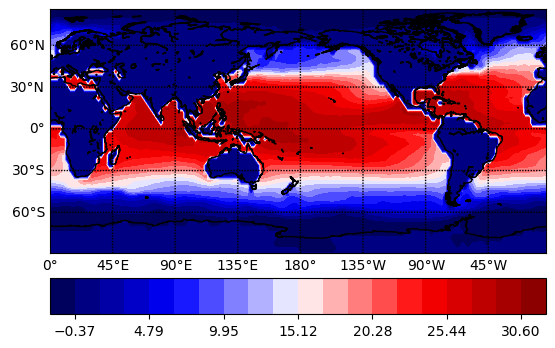

Month: 5


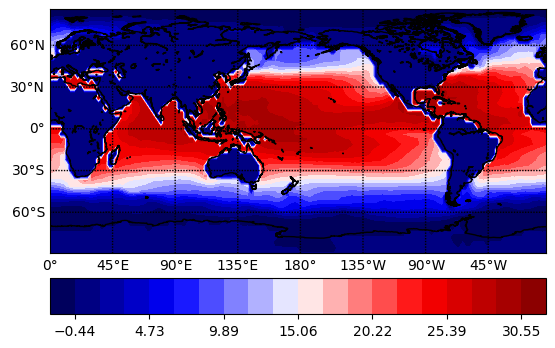

Month: 6


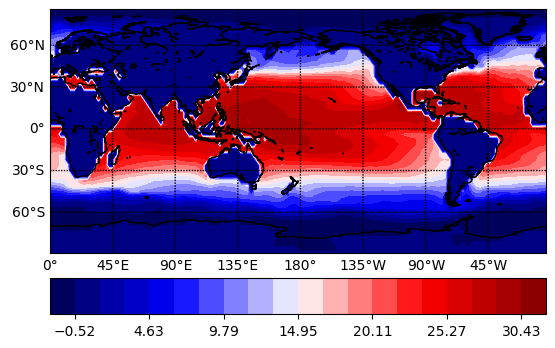

Month: 7


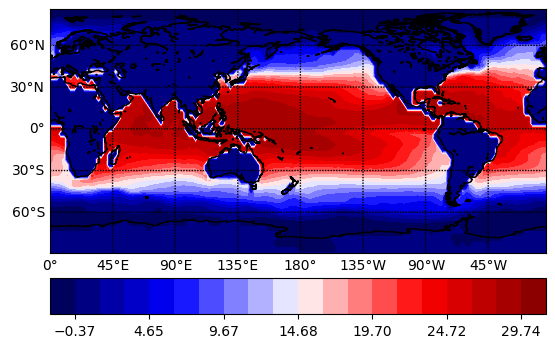

Month: 8


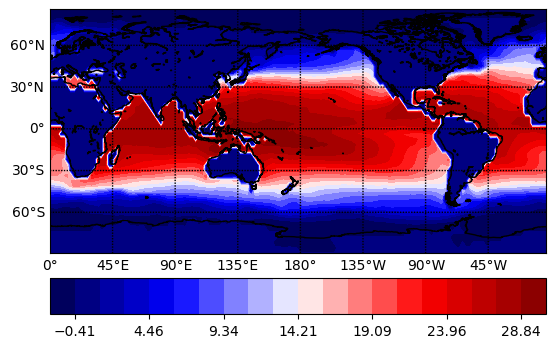

Month: 9


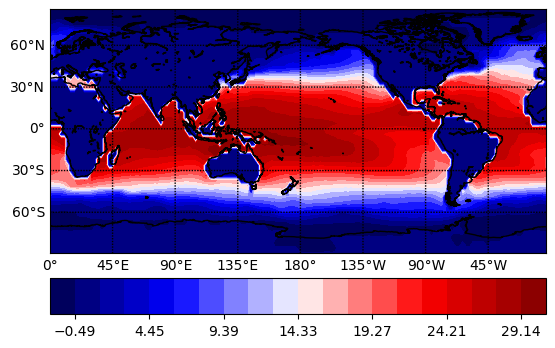

Month: 10


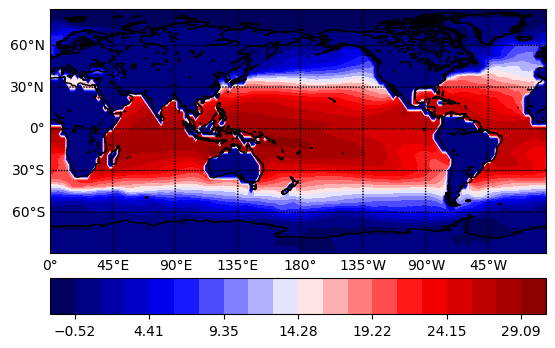

Month: 11


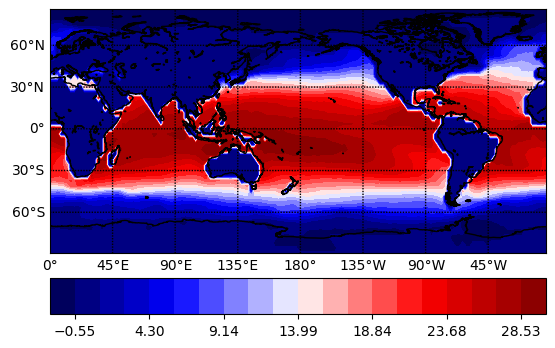

Month: 12


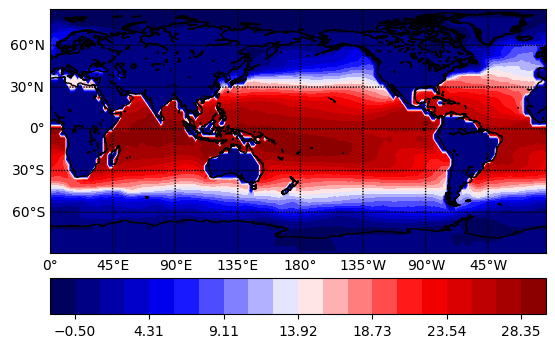

Error vs lead time plot saved to: error_vs_leadtime.png

Evaluation Complete!

Generated files:
  - sample_predictions.png
  - rollout_comparison.png
  - error_vs_leadtime.png


<Figure size 640x480 with 0 Axes>

In [8]:
# ============================================================================
# Main Test Script
# ============================================================================


"""Main testing and evaluation script."""

# Configuration
CHECKPOINT_PATH = './checkpoints_COBE/best_model.pth'
# DATASET_PATH = '../../Data/CMIP6-SST/GISS-E2-1-H_historical_1850_2014.nc'
# DATASET_PATH = '../../Data/CMIP6-SST/MIROC6_historical_1850_2014.nc'
# DATASET_PATH = '../../Data/CMIP6-SST/EC_Earth3_CC_historical_1850_2014.nc'  
DATASET_PATH = '../../Data/COBE_SST_resize.nc'
MASK_PATH = '../../Data/mask.npy'
N_TRAIN = 1428
N_VAL = 100
ENSEMBLE_ID = 1

device = 'cuda' #if torch.cuda.is_available() else 'cpu'

# Load model
generator, climatology, norm_params, num_input_months = load_trained_model(
    CHECKPOINT_PATH, device
)

# Load test data
_, _, test_data, _, _, test_months, mask = load_and_process_cobe_data(
    DATASET_PATH, MASK_PATH, N_TRAIN, N_VAL, ENSEMBLE_ID
)

# Normalize test data with same parameters
from train_cmip6_sst import normalize_data
_, _, test_data_norm, _ = normalize_data(
    test_data, test_data, test_data, method=norm_params['method']
)

if norm_params['method'] == 'standardize':
    test_data_norm = (test_data - norm_params['mean']) / norm_params['std']
elif norm_params['method'] == 'minmax':
    test_data_norm = (test_data - norm_params['min']) / (norm_params['max'] - norm_params['min'])
else:
    test_data_norm = test_data

# 1. Single-step evaluation
metrics = evaluate_single_step(
    generator, test_data_norm, test_months, num_input_months,
    climatology, norm_params, device
)

# 2. Rollout evaluation
rollout_results = evaluate_rollout(
    generator, test_data_norm, test_months, num_input_months,
    climatology, norm_params, num_rollout_months=480, num_rollouts=1, device=device
)


# 3. Compare with climatology
skill_score = compare_with_climatology(
    metrics['predictions'], metrics['targets'], metrics['months'],
    climatology, norm_params
)

# 4. Visualizations
print("\nGenerating visualizations...")
plot_sample_predictions(metrics['predictions'], metrics['targets'], 
                        metrics['months'], num_samples=6)
plot_rollout_comparison(rollout_results)
plot_error_vs_lead_time(rollout_results)

print("\n" + "="*70)
print("Evaluation Complete!")
print("="*70)
print("\nGenerated files:")
print("  - sample_predictions.png")
print("  - rollout_comparison.png")
print("  - error_vs_leadtime.png")


In [9]:
# squeeze out the singleton rollout dimension
data = rollout_results['predictions'].squeeze()      # (time, lat, lon)
save_rollout_to_netcdf(data, lat_sst, lon_sst, '../../Data/output/Observed/Updated/rollout_predictions_cobe_full.nc')

written ../../Data/output/Observed/Updated/rollout_predictions_cobe_full.nc  (480 time steps, 48 lat, 144 lon)


In [10]:
save_rollout_to_netcdf(test_data_norm, lat_sst, lon_sst, '../../Data/output/Observed/Updated/cobe_raw.nc')

written ../../Data/output/Observed/Updated/cobe_raw.nc  (671 time steps, 48 lat, 144 lon)


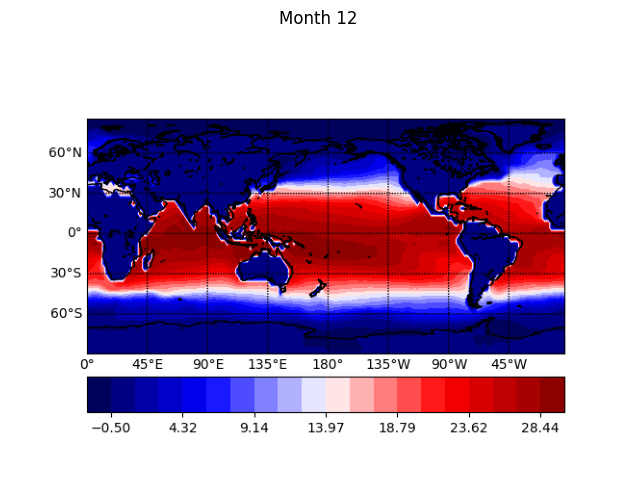

In [14]:
from PIL import Image
import os

import matplotlib.pyplot as plt
import matplotlib.animation as animation

# Create a list to store image filenames
image_files = []
for i in range(12):
    image_path = f'../../Data/output/Temp/seasonal_pattern{i+1}.png'
    if os.path.exists(image_path):
        image_files.append(image_path)

# Create figure and axis
fig, ax = plt.subplots(figsize=(10, 6))

# Function to update animation
def update(frame):
    ax.clear()
    img = Image.open(image_files[frame])
    ax.imshow(img)
    ax.axis('off')
    ax.set_title(f'Month {frame + 1}')

# Create animation
ani = animation.FuncAnimation(fig, update, frames=len(image_files), repeat=True, interval=500)

# Save or display animation
ani.save('../../Data/output/Observed/Updated/seasonal_animation.gif', writer='pillow')
plt.show()